In [1]:
import neptune
import os
from pathlib import Path
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

/groups/hephy/cms/alikaan.gueven/conda/envs/SDV/lib/python3.11/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [ ]:
api_token = Path.home().joinpath("neptune_api_keys/api_token.txt").read_text().strip()
os.environ["NEPTUNE_API_TOKEN"] = api_token

project = neptune.init_project(
    project="alikaan.guven/ParT", 
    mode="read-only",
)

In [4]:
runs = project.fetch_runs_table(id=["PART-746", "PART-747"])
df = runs.to_pandas()
df

,sys/creation_time,sys/description,sys/failed,sys/group_tags,sys/hostname,sys/id,sys/modification_time,sys/monitoring_time,sys/name,sys/owner,...,monitoring/56977f42/cpu,monitoring/56977f42/gpu,monitoring/56977f42/gpu_memory,monitoring/56977f42/gpu_power,monitoring/56977f42/hostname,monitoring/56977f42/memory,monitoring/56977f42/pid,monitoring/56977f42/stderr,monitoring/56977f42/stdout,monitoring/56977f42/tid
0,2025-10-26 19:42:16.034,,False,,clip-g3-1.cbe.vbc.ac.at,PART-747,2025-10-27 07:41:34.577,43156,PART-747,alikaan.guven,...,44.4,86.0,18.519409,184.139,clip-g3-1.cbe.vbc.ac.at,40.926075,15704,/groups/hephy/cms/alikaan.gueven/conda/envs/SD...,\n,140701285799744
1,2025-10-26 19:42:16.025,,False,,clip-g3-1.cbe.vbc.ac.at,PART-746,2025-10-28 10:41:07.376,42617,PART-746,alikaan.guven,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [75]:
DOWNLOADDIR = os.path.expandvars("/scratch-cbe/users/$USER/neptune_downloads")
os.makedirs(DOWNLOADDIR, exist_ok=True)

In [76]:
for i in range(745, 816+1):
    run_id = f"PART-{i}"
    RUNDIR = os.path.join(DOWNLOADDIR, run_id)
    os.makedirs(RUNDIR, exist_ok=True)
    table = project.fetch_runs_table(id=run_id)
    run = table.to_rows()[0]
    attributes = run.__dict__['_attributes']
    for attribute in attributes:
        key = attribute.__dict__['path']
        if key.startswith("Z/") or key.startswith("noncl/"):
            run[key].download(RUNDIR)
    print("Downloaded arrays for ", run_id)
    break

Downloaded arrays for  PART-745


In [ ]:
# project.stop()

In [71]:
DOWNLOADDIR

'/tmp/alikaan.gueven/neptune_downloads'

# SECOND CHAPTER

In [ ]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

In [3]:
run_base_dir = os.path.expandvars("/groups/hephy/cms/alikaan.gueven/ParT/runs")
run = "vtx_PART-745"
array_dir = os.path.join(run_base_dir, "vtx_PART-745/training/arrays")
array_dir


'/groups/hephy/cms/alikaan.gueven/ParT/runs/vtx_PART-745/training/arrays'

In [4]:
from pathlib import Path
import re

def find_max_epoch(directory: str):
    path = Path(directory)
    
    patterns = {
        "noncl": re.compile(r"p1p2_noncl_0\.0_epoch(\d+)\.npy$"),
        "Z":     re.compile(r"p1p2_Z_epoch(\d+)\.npy$")
    }

    max_epochs = {key: -1 for key in patterns}

    for file in path.glob("*.npy"):
        for key, pattern in patterns.items():
            m = pattern.search(file.name)
            if m:
                epoch = int(m.group(1))
                max_epochs[key] = max(max_epochs[key], epoch)
    
    # return max_epochs
    common_max = min(max_epochs.values())
    return common_max

745
746
747
748
749
750
751
752
753
754
755
756
757
758
759
760
761
762
763
764
765
766
767
768
769
770
771
772
773
774
775
776
777
778
779
780
781
782
783
784
785
786
787
788
789
790
791
792
793
794
795
796
797
798
799
800
801
802
803
804
805
806
807
808
809
810
811
812
813
814
815
816


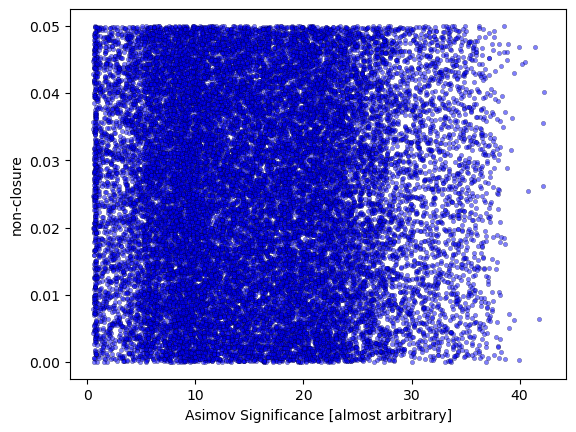

In [23]:
plt.figure()
run_base_dir = os.path.expandvars("/groups/hephy/cms/alikaan.gueven/ParT/runs")

goodList = []

for runNumber in range(745, 816+1):
    runName = f"vtx_PART-{runNumber}"
    array_dir = os.path.join(run_base_dir, f"{runName}/training/arrays")


    max_epoch = find_max_epoch(array_dir)

    for epoch in range(max_epoch + 1):
        bW = 0.025 # bin width
        x_thresh = np.arange(0.0, 1.0+bW, bW)
        y_thresh = np.arange(0.0, 1.0+bW, bW)

        arr_name = f"p1p2_Z_epoch{epoch}.npy"
        arr_path = os.path.join(array_dir, arr_name)
        Z = np.load(arr_path)

        arr_name = f"p1p2_noncl_0.0_epoch{epoch}.npy"
        arr_path = os.path.join(array_dir, arr_name)
        noncl0 = np.load(arr_path)

        noncl0_flat = noncl0.ravel()
        Z_flat = Z.ravel()
        filter = noncl0_flat < 0.05

        noncl0_flat = noncl0_flat[filter]
        Z_flat = Z_flat[filter]

        if Z_flat.size>0 and Z_flat.max() > 41:
            goodPoint = f"{runNumber}_{epoch}"
            if goodPoint not in goodList:
                goodList.append(f"{runNumber}_{epoch}")

        # arr_name = "p1p2_noncl_0.5_epoch{epoch}.npy"
        # arr_path = os.path.join(array_dir, arr_name)
        # noncl5 = np.load(arr_path)

        plt.scatter(Z_flat, noncl0_flat, color="blue", alpha=0.5, s=10, edgecolors="k", linewidths=0.3)
    print(runNumber)

plt.xlabel("Asimov Significance [almost arbitrary]")
plt.ylabel("non-closure")
plt.show()
# df = pd.DataFrame(data=arr,
#                   columns=y_thresh,
#                   index=x_thresh,
#                   dtype= float)

In [19]:
goodList

['770_83', '796_15', '812_27', '812_34']

770: 0.0001  0.1, 0.05,  75
796: 0.0003, 0.1, 0.10, 100
812: 0.0003, 0.1, 0.10, 100

In [26]:
x_thresh

array([0.   , 0.025, 0.05 , 0.075, 0.1  , 0.125, 0.15 , 0.175, 0.2  ,
       0.225, 0.25 , 0.275, 0.3  , 0.325, 0.35 , 0.375, 0.4  , 0.425,
       0.45 , 0.475, 0.5  , 0.525, 0.55 , 0.575, 0.6  , 0.625, 0.65 ,
       0.675, 0.7  , 0.725, 0.75 , 0.775, 0.8  , 0.825, 0.85 , 0.875,
       0.9  , 0.925, 0.95 , 0.975, 1.   ])

In [120]:
min(noncl0.ravel()[np.isfinite(noncl0).ravel()])

0.9804726479089563

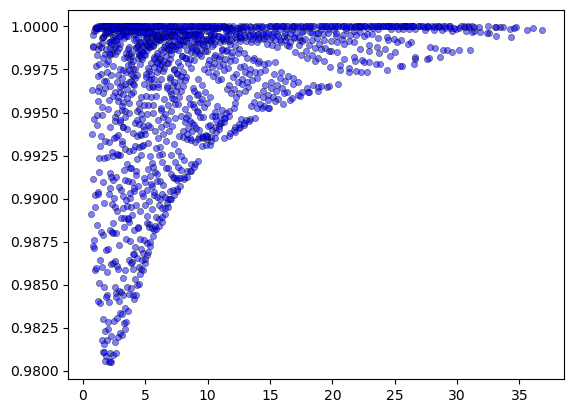

In [ ]:
plt.scatter(Z.ravel(), noncl0.ravel(), color="blue", alpha=0.5, s=20, edgecolors="k", linewidths=0.5)

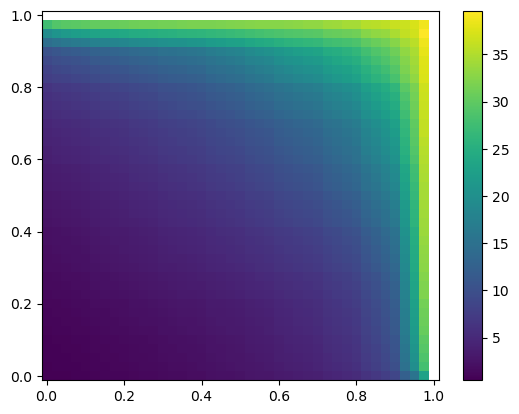

In [ ]:
pcm = plt.pcolormesh(df.index, df.columns, df.values.T, shading='auto')
cbar = plt.colorbar(pcm)